<a href="https://colab.research.google.com/github/ajaykumar080286/feature_engineering/blob/main/9_standardization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [205]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np


In [206]:
df=pd.read_csv("https://raw.githubusercontent.com/ajaykumar080286/feature_engineering/main/Social_Network_Ads.csv")

In [207]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


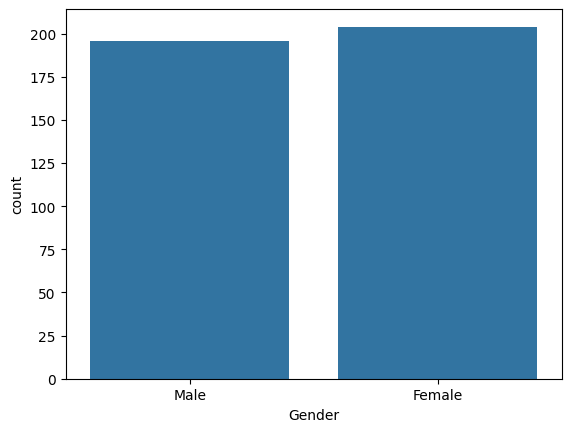

In [208]:
sns.countplot(x=df["Gender"])
plt.show()

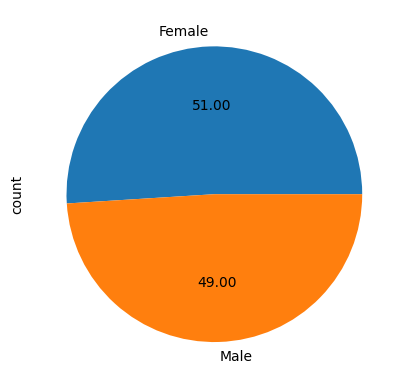

In [209]:
df["Gender"].value_counts().plot(kind="pie", autopct="%.2f")
plt.show()

<Axes: xlabel='Age', ylabel='Count'>

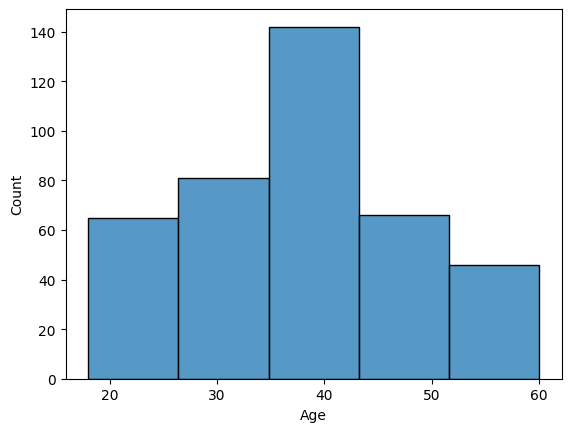

In [210]:
sns.histplot(x=df["Age"],bins=5)

<Axes: xlabel='Age', ylabel='EstimatedSalary'>

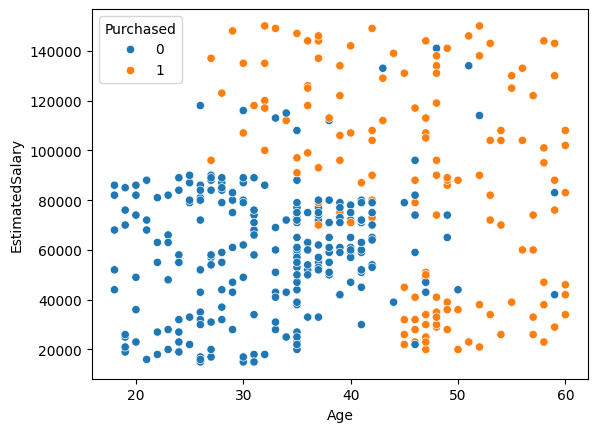

In [211]:
sns.scatterplot(x=df["Age"], y=df["EstimatedSalary"], hue="Purchased", data=df)


In [212]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [213]:
df.isnull().sum()

,0
User ID,0
Gender,0
Age,0
EstimatedSalary,0
Purchased,0


<Axes: xlabel='Purchased', ylabel='Age'>

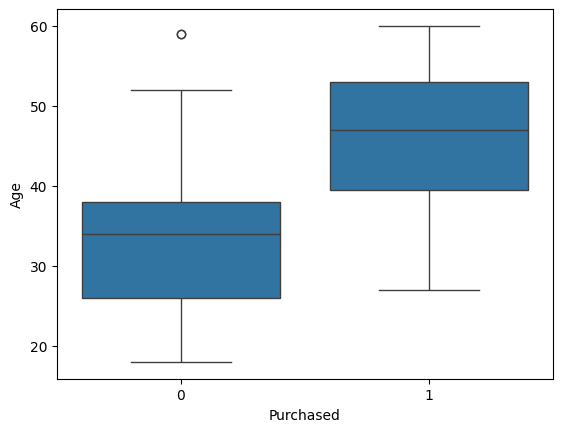

In [214]:
sns.boxplot(x=df["Purchased"],y=df["Age"])

<Axes: xlabel='Purchased', ylabel='Age'>

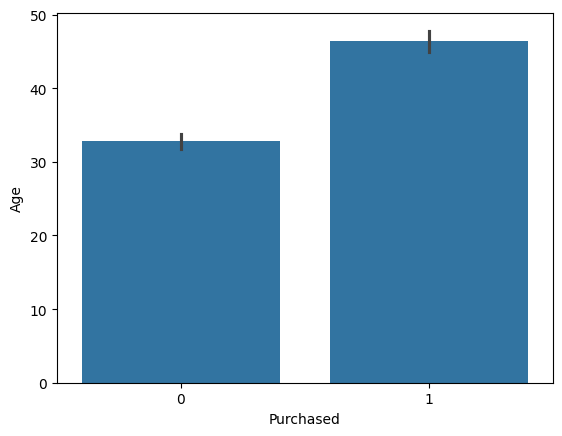

In [215]:
sns.barplot(x=df["Purchased"],y=df["Age"])

In [216]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [217]:
df=df.iloc[:,2:]

In [218]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [219]:
x=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [220]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [221]:
X_train.shape

(320, 2)

**StandardScaler**

In [222]:
scaller=StandardScaler()
scaller.fit(X_train)

StandardScaler()

In [223]:
X_train_scaled=scaller.transform(X_train)
X_test_scaled=scaller.transform(X_test)

In [224]:
scaller.mean_

array([3.8218750e+01, 6.9928125e+04])

In [225]:
X_train

,Age,EstimatedSalary
336,58,144000
64,59,83000
55,24,55000
106,26,35000
300,58,38000
...,...,...
323,48,30000
192,29,43000
117,36,52000
47,27,54000


In [226]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_train.columns)

In [227]:
X_train_scaled

,Age,EstimatedSalary
0,1.922950,2.146016
1,2.020161,0.378719
2,-1.382215,-0.432499
3,-1.187794,-1.011940
4,1.922950,-0.925024
...,...,...
315,0.950843,-1.156800
316,-0.896162,-0.780164
317,-0.215686,-0.519415
318,-1.090583,-0.461471


In [228]:
X_test_scaled

,Age,EstimatedSalary
0,-0.798951,0.494608
1,-0.021265,-0.577359
2,-0.312897,0.146943
3,-0.798951,0.262831
4,-0.312897,-0.577359
...,...,...
75,-1.965480,0.349747
76,0.367578,0.262831
77,0.173157,-0.287638
78,1.436896,-1.040912


In [229]:
X_train.describe()

,Age,EstimatedSalary
count,320.00000,320.000000
mean,38.21875,69928.125000
std,10.30304,34570.057299
min,18.00000,15000.000000
25%,30.00000,43000.000000
50%,38.00000,69500.000000
75%,46.00000,88000.000000
max,60.00000,150000.000000


In [230]:
np.round(X_train_scaled.describe(),2)

,Age,EstimatedSalary
count,320.00,320.00
mean,0.00,0.00
std,1.00,1.00
min,-1.97,-1.59
25%,-0.80,-0.78
50%,-0.02,-0.01
75%,0.76,0.52
max,2.12,2.32


**Effect of Scaling**

Text(0, 0.5, 'EstimatedSalary')

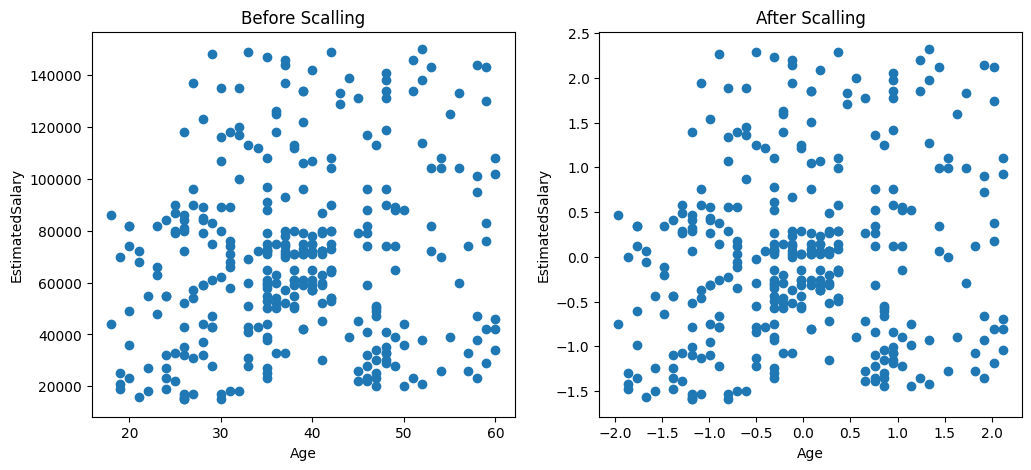

In [231]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train["Age"], X_train["EstimatedSalary"])
ax1.set_title("Before Scalling")
ax1.set_xlabel("Age")
ax1.set_ylabel("EstimatedSalary")

ax2.scatter(X_train_scaled["Age"], X_train_scaled["EstimatedSalary"])
ax2.set_title("After Scalling")
ax2.set_xlabel("Age")
ax2.set_ylabel("EstimatedSalary")

<Axes: title={'center': 'Before Scalling'}, xlabel='Age', ylabel='Density'>

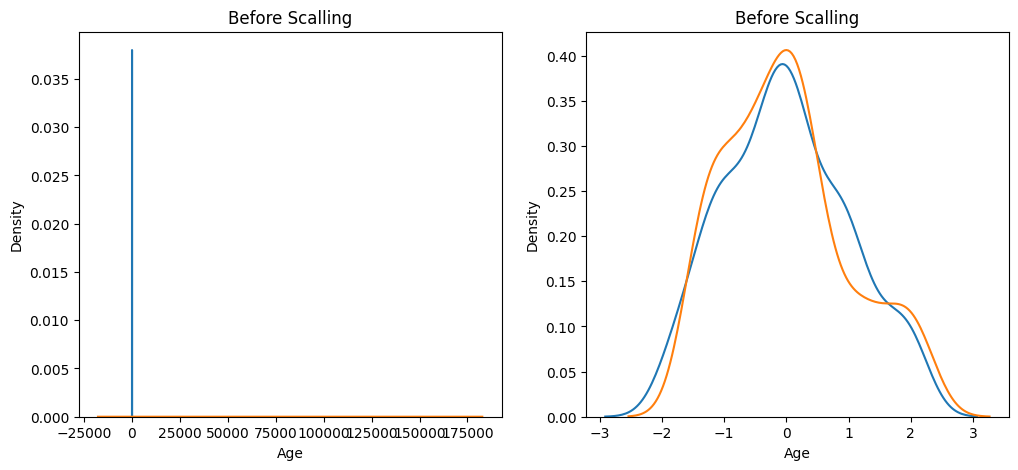

In [232]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.set_title("Before Scalling")
sns.kdeplot(x=X_train["Age"],ax=ax1)
sns.kdeplot(x=X_train["EstimatedSalary"],ax=ax1)


ax2.set_title("Before Scalling")
sns.kdeplot(x=X_train_scaled["Age"],ax=ax2)
sns.kdeplot(x=X_train_scaled["EstimatedSalary"],ax=ax2)


**Comparison of Distributions**

<Axes: title={'center': 'After  Scalling Age'}, xlabel='Age', ylabel='Density'>

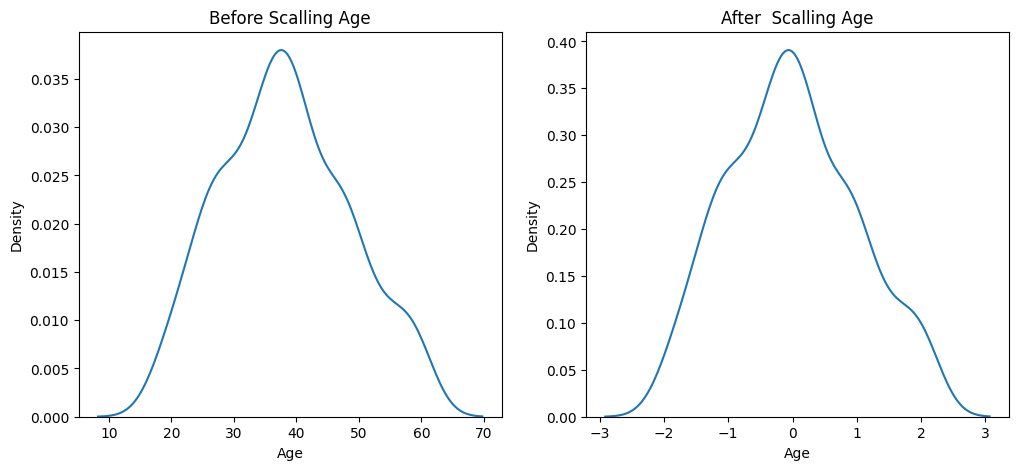

In [233]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.set_title("Before Scalling Age")
sns.kdeplot(x=X_train["Age"],ax=ax1)


ax2.set_title("After  Scalling Age")
sns.kdeplot(x=X_train_scaled["Age"],ax=ax2)


<Axes: title={'center': 'After Scalling EstimatedSalary'}, xlabel='EstimatedSalary', ylabel='Density'>

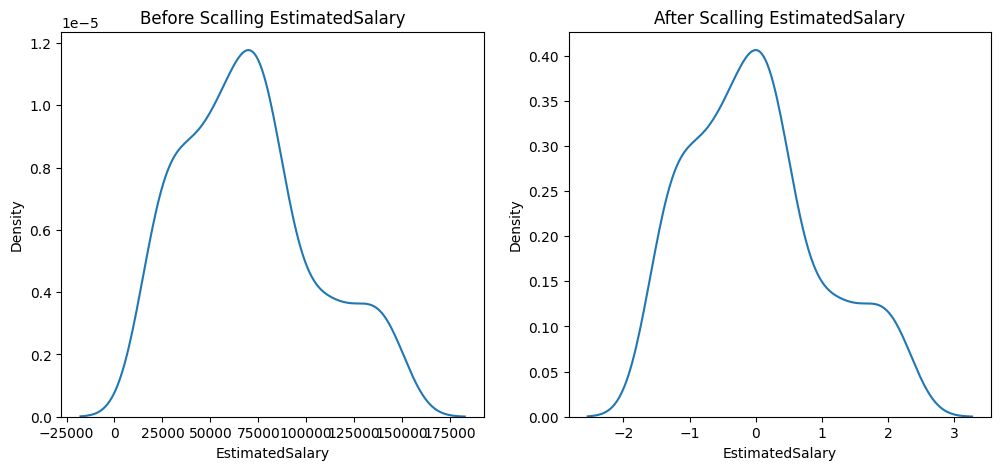

In [234]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.set_title("Before Scalling EstimatedSalary")
sns.kdeplot(x=X_train["EstimatedSalary"],ax=ax1)

ax2.set_title("After Scalling EstimatedSalary")
sns.kdeplot(x=X_train_scaled["EstimatedSalary"],ax=ax2)


Text(0, 0.5, 'EstimatedSalary')

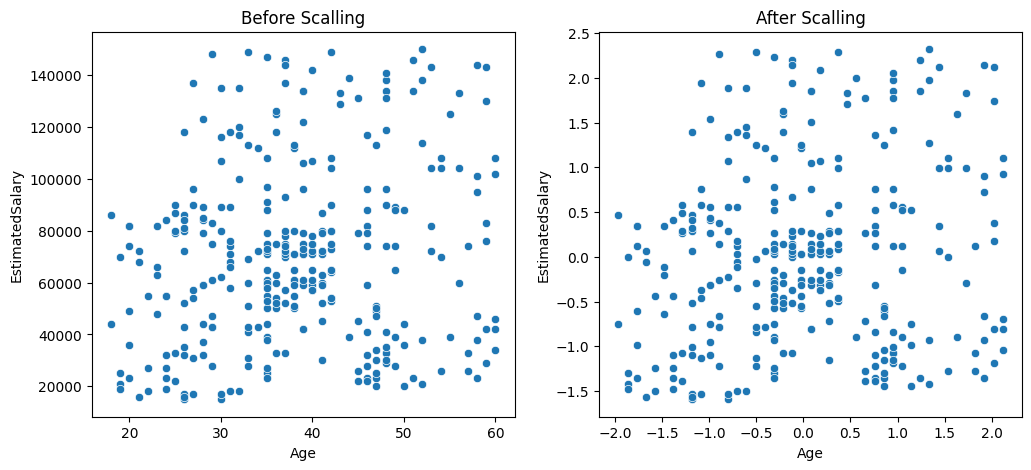

In [235]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

sns.scatterplot(x=X_train["Age"], y=X_train["EstimatedSalary"],ax=ax1)
ax1.set_title("Before Scalling")
ax1.set_xlabel("Age")
ax1.set_ylabel("EstimatedSalary")

sns.scatterplot(x=X_train_scaled["Age"], y=X_train_scaled["EstimatedSalary"],ax=ax2)
ax2.set_title("After Scalling")
ax2.set_xlabel("Age")
ax2.set_ylabel("EstimatedSalary")

**Why scaling is important?**

In [236]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import  accuracy_score

In [237]:
lr=LogisticRegression()

lr.fit(X_train,y_train)
y_pred=lr.predict(X_test)
accuracy_score(y_test, y_pred)

0.9125

In [238]:
lr1=LogisticRegression()

lr1.fit(X_train_scaled,y_train)
y_pred1=lr1.predict(X_test_scaled)
accuracy_score(y_test, y_pred1)

0.925

In [239]:
dt=DecisionTreeClassifier()

dt.fit(X_train,y_train)
y_pred=dt.predict(X_test)
accuracy_score(y_test, y_pred)

0.9125

In [240]:
dt1=DecisionTreeClassifier()

dt1.fit(X_train_scaled,y_train)
y_pred1=dt1.predict(X_test_scaled)
accuracy_score(y_test, y_pred1)

0.9

In [241]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [242]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


<Axes: ylabel='EstimatedSalary'>

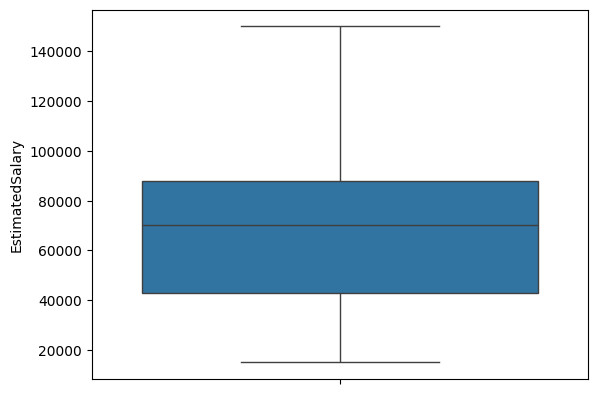

In [243]:
sns.boxplot(df["EstimatedSalary"])

In [258]:
new_data = pd.DataFrame(
    {
    "Age":[5,90,95],
    "EstimatedSalary":[1000,250000,350000],
    'Purchased':[0,1,1]
    }
)
new_df = pd.concat([df, new_data], ignore_index=True)

In [259]:
new_df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
398,36,33000,0
399,49,36000,1
400,5,1000,0
401,90,250000,1


In [260]:
X1=new_df.iloc[:,0:2]
y1=new_df.iloc[:,-1]

In [261]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X1,y1, test_size=0.3, random_state=0)

In [262]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

In [263]:
sc.fit(X_train)

StandardScaler()

In [264]:
X_train_trans=sc.transform(X_train)
X_test_trans=sc.transform(X_test)


In [265]:
X_train_trans=pd.DataFrame(X_train_trans, columns=X_train.columns)
X_test_trans=pd.DataFrame(X_test_trans, columns=X_train.columns)

In [266]:
X_train_trans

,Age,EstimatedSalary
0,-0.652473,-0.995561
1,1.903047,2.092697
2,-0.104862,1.922701
3,-0.652473,0.562734
4,-0.013593,-0.287245
...,...,...
277,0.899092,-1.108891
278,-0.835010,-0.740567
279,-0.196130,-0.485573
280,-1.017547,-0.428908


Text(0, 0.5, 'EstimatedSalary')

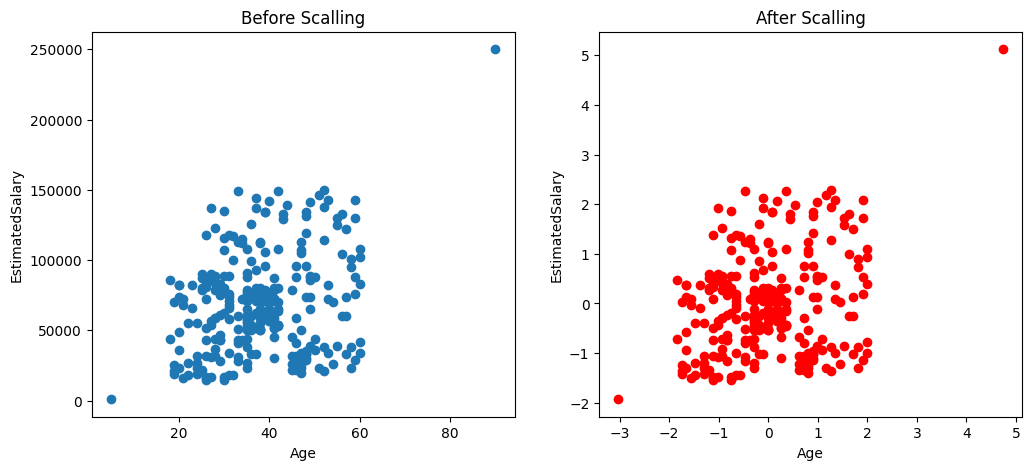

In [267]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train["Age"], X_train["EstimatedSalary"])
ax1.set_title("Before Scalling")
ax1.set_xlabel("Age")
ax1.set_ylabel("EstimatedSalary")

ax2.scatter(X_train_trans["Age"], X_train_trans["EstimatedSalary"],color='red')
ax2.set_title("After Scalling")
ax2.set_xlabel("Age")
ax2.set_ylabel("EstimatedSalary")


<Axes: xlabel='Age', ylabel='EstimatedSalary'>

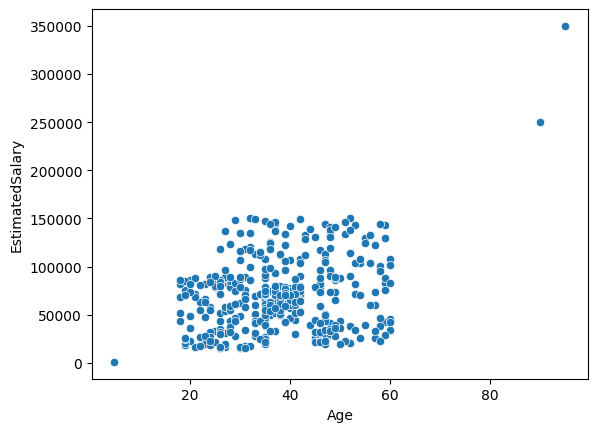

In [268]:
sns.scatterplot(x=new_df["Age"], y=new_df["EstimatedSalary"])

<Axes: xlabel='Age', ylabel='EstimatedSalary'>

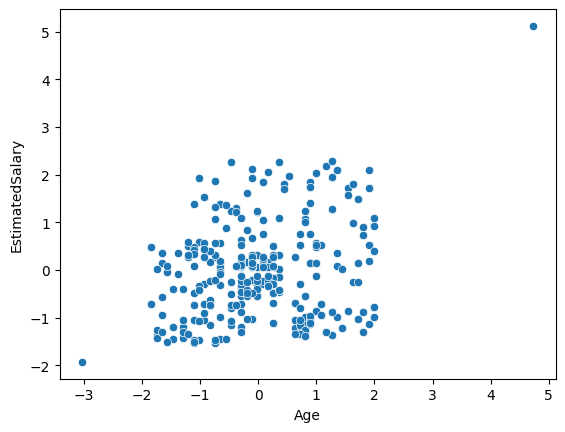

In [269]:
sns.scatterplot(x=X_train_trans["Age"], y=X_train_trans["EstimatedSalary"])